# Load libraries

In [25]:
import sys
!{sys.executable} -m pip install pandas numpy matplotlib scikit-learn seaborn umap-learn scipy xgboost shap PyALE


[notice] A new release of pip is available: 24.0 -> 25.3
[notice] To update, run: pip3 install --upgrade pip


In [26]:
import pandas as pd
pd.set_option('display.max_columns', None)

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import colormaps  # Ensure this is imported
import matplotlib.dates as mdates
from matplotlib.gridspec import GridSpec
import seaborn as sns
import math
import json
from sklearn.model_selection import StratifiedShuffleSplit, StratifiedKFold
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.metrics import root_mean_squared_error, r2_score
import shap
from PyALE import ale
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from scipy.stats import linregress, spearmanr
from sklearn.model_selection import TimeSeriesSplit
from itertools import product

# Loading the data

In [27]:
chamau_lag = pd.read_csv("../datasets/Chamau_2014-2024_clean_newlag.csv")
chamau_daily = pd.read_csv("../datasets/Chamau_Daily_2014-2024_newlag.csv")
oensingen_1_lag = pd.read_csv("../datasets/Oensingen_2018-19_clean_newlag.csv")
oensingen_1_daily = pd.read_csv("../datasets/Oensingen_Daily_2018-19_newlag.csv")
oensingen_2_lag = pd.read_csv("../datasets/Oensingen_2021-23_clean_newlag.csv")
oensingen_2_daily = pd.read_csv("../datasets/Oensingen_Daily_2021-23_newlag.csv")
aeschi_lag = pd.read_csv("../datasets/Aeschi_2019-20_clean_newlag.csv")
aeschi_daily = pd.read_csv("../datasets/Aeschi_Daily_2019-20_newlag.csv")
forel_lag = pd.read_csv("../datasets/Forel_2024-25_clean_newlag.csv")
forel_daily = pd.read_csv("../datasets/Forel_Daily_2024-25_newlag.csv")
tanikon_lag = pd.read_csv("../datasets/Tanikon_2023-25_clean_newlag.csv")
tanikon_daily = pd.read_csv("../datasets/Tanikon_Daily_2023-25_newlag.csv")

# Fine tuning functions

In [28]:
def hyperparameter_search_timeseries(df, predictors, target, test_size=0.1, 
                                     search_type='random', n_iter=200, random_state=42):
    """
    Perform hyperparameter search for XGBoost on time-series data.
    
    Parameters:
    -----------
    search_type : str
        'grid' for exhaustive grid search, 'random' for random search
    n_iter : int
        Number of iterations for random search
    """
    
    # PREPARE DATA
    df = df.sort_index().copy()
    X = df[predictors]
    y = df[target]
    
    # HANDLE NaNs
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    # OFFSET FOR POSITIVITY
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    # CHRONOLOGICAL SPLIT
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    
    # DEFINE HYPERPARAMETER SPACE
    param_grid = {
        'n_estimators': [100, 200, 300, 500],
        'max_depth': [3, 4, 5, 6, 8],
        'learning_rate': [0.01, 0.05, 0.1, 0.2],
        'subsample': [0.6, 0.7, 0.8, 0.9],
        'colsample_bytree': [0.6, 0.7, 0.8, 0.9],
        'min_child_weight': [1, 3, 5],
        'gamma': [0, 0.1, 0.2, 0.5],
    }
    
    print("Starting hyperparameter search...")
    print(f"Search type: {search_type}")
    
    best_score = -np.inf
    best_params = None
    results = []
    
    if search_type == 'grid':
        # GRID SEARCH (can be very slow!)
        param_combinations = list(product(*param_grid.values()))
        print(f"Total combinations: {len(param_combinations)}")
        
        for i, params in enumerate(param_combinations[:n_iter]):  # Limit iterations
            param_dict = dict(zip(param_grid.keys(), params))
            score, metrics = _evaluate_params(X_train, y_train, X_test, y_test, 
                                             param_dict, offset, random_state)
            results.append({**param_dict, **metrics})
            
            if score > best_score:
                best_score = score
                best_params = param_dict
            
            if (i + 1) % 10 == 0:
                print(f"Completed {i + 1} iterations. Best R²: {best_score:.4f}")
    
    else:  # RANDOM SEARCH
        print(f"Random search iterations: {n_iter}")
        
        for i in range(n_iter):
            # Sample random parameters
            param_dict = {
                'n_estimators': np.random.choice(param_grid['n_estimators']),
                'max_depth': np.random.choice(param_grid['max_depth']),
                'learning_rate': np.random.choice(param_grid['learning_rate']),
                'subsample': np.random.choice(param_grid['subsample']),
                'colsample_bytree': np.random.choice(param_grid['colsample_bytree']),
                'min_child_weight': np.random.choice(param_grid['min_child_weight']),
                'gamma': np.random.choice(param_grid['gamma']),
            }
            
            score, metrics = _evaluate_params(X_train, y_train, X_test, y_test, 
                                             param_dict, offset, random_state)
            results.append({**param_dict, **metrics})
            
            if score > best_score:
                best_score = score
                best_params = param_dict
            
            if (i + 1) % 10 == 0:
                print(f"Completed {i + 1}/{n_iter} iterations. Best R²: {best_score:.4f}")
    
    # CONVERT RESULTS TO DATAFRAME
    results_df = pd.DataFrame(results).sort_values('r2', ascending=False)
    
    print("\n" + "="*60)
    print("HYPERPARAMETER SEARCH COMPLETE")
    print("="*60)
    print("\nBest parameters:")
    for key, value in best_params.items():
        print(f"  {key}: {value}")
    print(f"\nBest R²: {best_score:.4f}")
    
    return best_params, results_df


def _evaluate_params(X_train, y_train, X_test, y_test, params, offset, random_state):
    """Helper function to evaluate a parameter set."""
    model = XGBRegressor(
        **params,
        random_state=random_state,
        n_jobs=-1
    )
    model.fit(X_train, y_train, verbose=False)
    
    y_pred = model.predict(X_test)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    return r2, {'r2': r2, 'spearman_rho': rho}

In [29]:
def train_final_model(df, predictors, target, best_params, test_size=0.1, 
                      random_state=42, plot=True):
    """
    Train final model with best hyperparameters and generate comprehensive plots.
    """
    # PREPARE DATA
    df = df.sort_index().copy()
    X = df[predictors]
    y = df[target]
    
    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset
    
    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]
    test_dates = X_test.index
    
    # TRAIN WITH BEST PARAMS
    model = XGBRegressor(**best_params, random_state=random_state, n_jobs=-1)
    model.fit(X_train, y_train, verbose=False)
    
    y_pred = model.predict(X_test)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset
    
    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)
    
    print("\n" + "="*60)
    print("FINAL MODEL PERFORMANCE")
    print("="*60)
    print(f"R² (linear scale): {r2:.4f}")
    print(f"Spearman ρ:        {rho:.4f}")
    
    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        
        # Scatter plot
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()
        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"Fine-tuned XGBoost (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        
        # Feature importance
        top_features = importances.head(15)
        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()
        
        # Time series comparison
        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)
        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        
        plt.tight_layout()
        plt.show()
    
    return {
        "model": model,
        "r2": r2,
        "spearman_rho": rho,
        "feature_importance": importances,
        "y_test": y_test_lin,
        "y_pred": y_pred_lin,
        "test_dates": test_dates,
        "best_params": best_params
    }

# Experiment 1: Chamau dataset

In [30]:
# FIX TIMESTAMP
chamau_lag['Timestamp'] = pd.to_datetime(chamau_lag['Timestamp'])
chamau_lag = chamau_lag.set_index('Timestamp').sort_index()

chamau_daily['Date'] = pd.to_datetime(chamau_daily['Date'])
chamau_daily = chamau_daily.sort_values('Date')

# SPLIT BY PARCEL
chamau_A = chamau_lag[chamau_lag['Parcel'] == 'A'].copy()
chamau_B = chamau_lag[chamau_lag['Parcel'] == 'B'].copy()
chamau_daily_A = chamau_daily[chamau_daily['Parcel'] == 'A'].set_index('Date')
chamau_daily_B = chamau_daily[chamau_daily['Parcel'] == 'B'].set_index('Date')

In [31]:
# Define base, lag and augmented lag predictors
base_predictors = [
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation"
]

lag_predictors = [
    # --- Meteorological base variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm",
    "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",

    # --- Meteorological lag variables ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",

    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]

augmented_predictors = [
    # --- Base current-day variables ---
    "Precipitation", "SolarRadiation", "AirTemp", "VPD",
    "SoilWater_5cm", "SoilWater_15cm", "SoilTemp_4cm", "SoilTemp_15cm",
    "NEE", "GPP", "RECO",
    
    # --- Lag features (1, 3, 5, 7 days) ---
    "NEE_lag1d_daily", "NEE_lag3d_daily", "NEE_lag5d_daily", "NEE_lag7d_daily",
    "GPP_lag1d_daily", "GPP_lag3d_daily", "GPP_lag5d_daily", "GPP_lag7d_daily",
    "RECO_lag1d_daily", "RECO_lag3d_daily", "RECO_lag5d_daily", "RECO_lag7d_daily",
    "SolarRadiation_lag1d_daily", "SolarRadiation_lag3d_daily", "SolarRadiation_lag5d_daily", "SolarRadiation_lag7d_daily",
    "AirTemp_lag1d_daily", "AirTemp_lag3d_daily", "AirTemp_lag5d_daily", "AirTemp_lag7d_daily",
    "VPD_lag1d_daily", "VPD_lag3d_daily", "VPD_lag5d_daily", "VPD_lag7d_daily",
    "SoilWater_5cm_lag1d_daily", "SoilWater_5cm_lag3d_daily", "SoilWater_5cm_lag5d_daily", "SoilWater_5cm_lag7d_daily",
    "SoilWater_15cm_lag1d_daily", "SoilWater_15cm_lag3d_daily", "SoilWater_15cm_lag5d_daily", "SoilWater_15cm_lag7d_daily",
    "SoilTemp_4cm_lag1d_daily", "SoilTemp_4cm_lag3d_daily", "SoilTemp_4cm_lag5d_daily", "SoilTemp_4cm_lag7d_daily",
    "SoilTemp_15cm_lag1d_daily", "SoilTemp_15cm_lag3d_daily", "SoilTemp_15cm_lag5d_daily", "SoilTemp_15cm_lag7d_daily",
    "Precipitation_lag1d_daily", "Precipitation_lag3d_daily", "Precipitation_lag5d_daily", "Precipitation_lag7d_daily",
    
    # --- Rolling mean features (3, 5, 7 day windows) ---
    "NEE_roll3d_mean", "NEE_roll5d_mean", "NEE_roll7d_mean",
    "GPP_roll3d_mean", "GPP_roll5d_mean", "GPP_roll7d_mean",
    "RECO_roll3d_mean", "RECO_roll5d_mean", "RECO_roll7d_mean",
    "SolarRadiation_roll3d_mean", "SolarRadiation_roll5d_mean", "SolarRadiation_roll7d_mean",
    "AirTemp_roll3d_mean", "AirTemp_roll5d_mean", "AirTemp_roll7d_mean",
    "VPD_roll3d_mean", "VPD_roll5d_mean", "VPD_roll7d_mean",
    "SoilWater_5cm_roll3d_mean", "SoilWater_5cm_roll5d_mean", "SoilWater_5cm_roll7d_mean",
    "SoilWater_15cm_roll3d_mean", "SoilWater_15cm_roll5d_mean", "SoilWater_15cm_roll7d_mean",
    "SoilTemp_4cm_roll3d_mean", "SoilTemp_4cm_roll5d_mean", "SoilTemp_4cm_roll7d_mean",
    "SoilTemp_15cm_roll3d_mean", "SoilTemp_15cm_roll5d_mean", "SoilTemp_15cm_roll7d_mean",
    "Precipitation_roll3d_mean", "Precipitation_roll5d_mean", "Precipitation_roll7d_mean",
    
    # --- Rolling sum features (3, 5, 7 day windows) ---
    "NEE_roll3d_sum", "NEE_roll5d_sum", "NEE_roll7d_sum",
    "GPP_roll3d_sum", "GPP_roll5d_sum", "GPP_roll7d_sum",
    "RECO_roll3d_sum", "RECO_roll5d_sum", "RECO_roll7d_sum",
    "SolarRadiation_roll3d_sum", "SolarRadiation_roll5d_sum", "SolarRadiation_roll7d_sum",
    "AirTemp_roll3d_sum", "AirTemp_roll5d_sum", "AirTemp_roll7d_sum",
    "VPD_roll3d_sum", "VPD_roll5d_sum", "VPD_roll7d_sum",
    "SoilWater_5cm_roll3d_sum", "SoilWater_5cm_roll5d_sum", "SoilWater_5cm_roll7d_sum",
    "SoilWater_15cm_roll3d_sum", "SoilWater_15cm_roll5d_sum", "SoilWater_15cm_roll7d_sum",
    "SoilTemp_4cm_roll3d_sum", "SoilTemp_4cm_roll5d_sum", "SoilTemp_4cm_roll7d_sum",
    "SoilTemp_15cm_roll3d_sum", "SoilTemp_15cm_roll5d_sum", "SoilTemp_15cm_roll7d_sum",
    "Precipitation_roll3d_sum", "Precipitation_roll5d_sum", "Precipitation_roll7d_sum",
    
    # --- Management variables ---
    "Mowing", "FertilizerOrganic", "FertilizerMineral", "Grazing", "SoilCultivation",
    "DaysSince_Mowing", "DaysSince_FertilizerOrganic", "DaysSince_FertilizerMineral",
    "DaysSince_Grazing", "DaysSince_SoilCultivation"
]


OPTIMIZING: Hourly | Base
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.2213
Completed 20/200 iterations. Best R²: 0.2213
Completed 30/200 iterations. Best R²: 0.2213
Completed 40/200 iterations. Best R²: 0.2213
Completed 50/200 iterations. Best R²: 0.2267
Completed 60/200 iterations. Best R²: 0.2464
Completed 70/200 iterations. Best R²: 0.2464
Completed 80/200 iterations. Best R²: 0.2464
Completed 90/200 iterations. Best R²: 0.2464
Completed 100/200 iterations. Best R²: 0.2464
Completed 110/200 iterations. Best R²: 0.2464
Completed 120/200 iterations. Best R²: 0.2464
Completed 130/200 iterations. Best R²: 0.2464
Completed 140/200 iterations. Best R²: 0.2464
Completed 150/200 iterations. Best R²: 0.2464
Completed 160/200 iterations. Best R²: 0.2464
Completed 170/200 iterations. Best R²: 0.2464
Completed 180/200 iterations. Best R²: 0.2464
Completed 190/200 iterations. Best R²: 0.2464
Completed 200/200 iterat

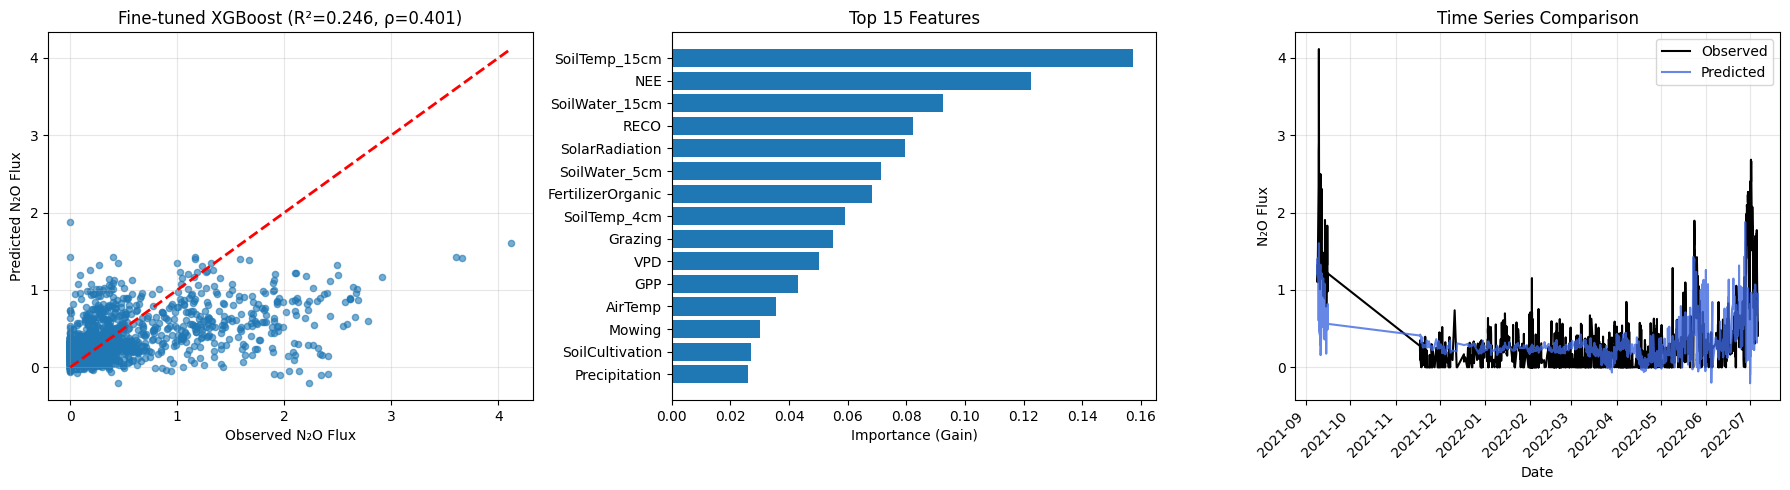


✓ Completed Hourly | Base
  Optimized R²: 0.2464
  Optimized ρ: 0.4009

OPTIMIZING: Hourly | Lag
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.3040
Completed 20/200 iterations. Best R²: 0.3058
Completed 30/200 iterations. Best R²: 0.3058
Completed 40/200 iterations. Best R²: 0.3058
Completed 50/200 iterations. Best R²: 0.3058
Completed 60/200 iterations. Best R²: 0.3138
Completed 70/200 iterations. Best R²: 0.3138
Completed 80/200 iterations. Best R²: 0.3138
Completed 90/200 iterations. Best R²: 0.3138
Completed 100/200 iterations. Best R²: 0.3247
Completed 110/200 iterations. Best R²: 0.3247
Completed 120/200 iterations. Best R²: 0.3328
Completed 130/200 iterations. Best R²: 0.3328
Completed 140/200 iterations. Best R²: 0.3328
Completed 150/200 iterations. Best R²: 0.3328
Completed 160/200 iterations. Best R²: 0.3328
Completed 170/200 iterations. Best R²: 0.3328
Completed 180/200 iterations. Best R²: 0.3328

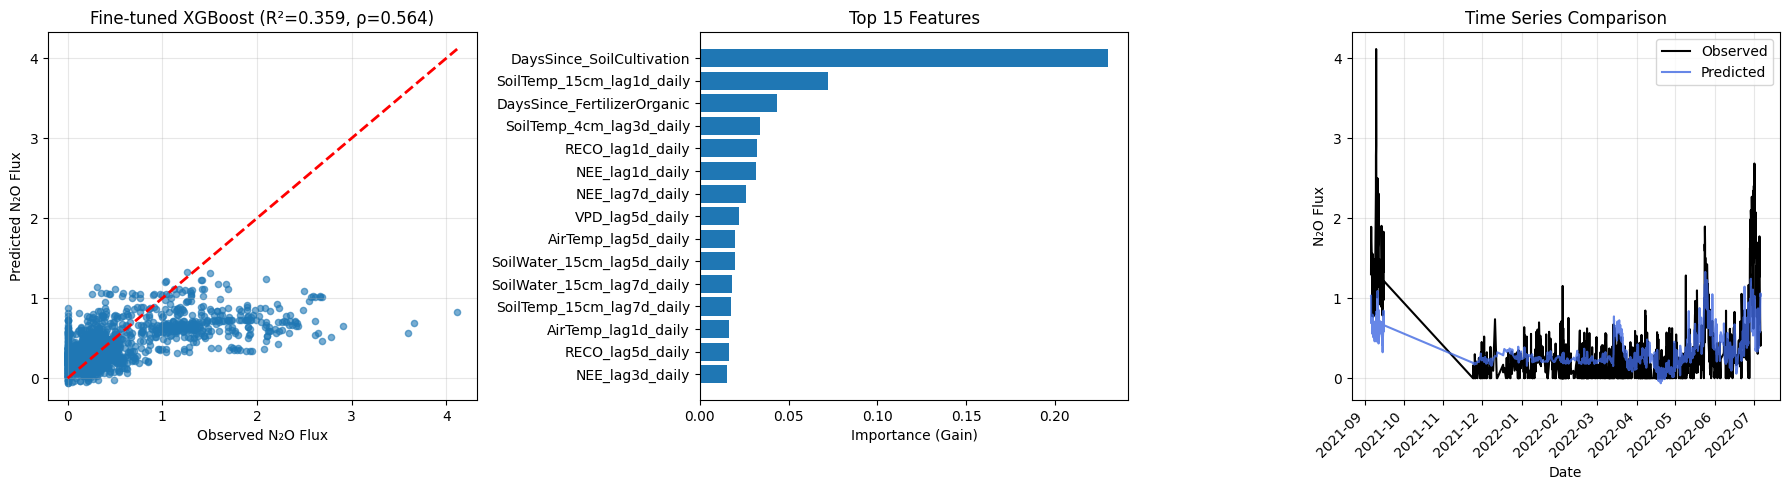


✓ Completed Hourly | Lag
  Optimized R²: 0.3589
  Optimized ρ: 0.5638

OPTIMIZING: Hourly | Augmented
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.3418
Completed 20/200 iterations. Best R²: 0.3474
Completed 30/200 iterations. Best R²: 0.3759
Completed 40/200 iterations. Best R²: 0.3759
Completed 50/200 iterations. Best R²: 0.3759
Completed 60/200 iterations. Best R²: 0.3759
Completed 70/200 iterations. Best R²: 0.3759
Completed 80/200 iterations. Best R²: 0.3759
Completed 90/200 iterations. Best R²: 0.3759
Completed 100/200 iterations. Best R²: 0.3759
Completed 110/200 iterations. Best R²: 0.3759
Completed 120/200 iterations. Best R²: 0.3759
Completed 130/200 iterations. Best R²: 0.3759
Completed 140/200 iterations. Best R²: 0.3759
Completed 150/200 iterations. Best R²: 0.3759
Completed 160/200 iterations. Best R²: 0.3759
Completed 170/200 iterations. Best R²: 0.3759
Completed 180/200 iterations. Best R²: 0

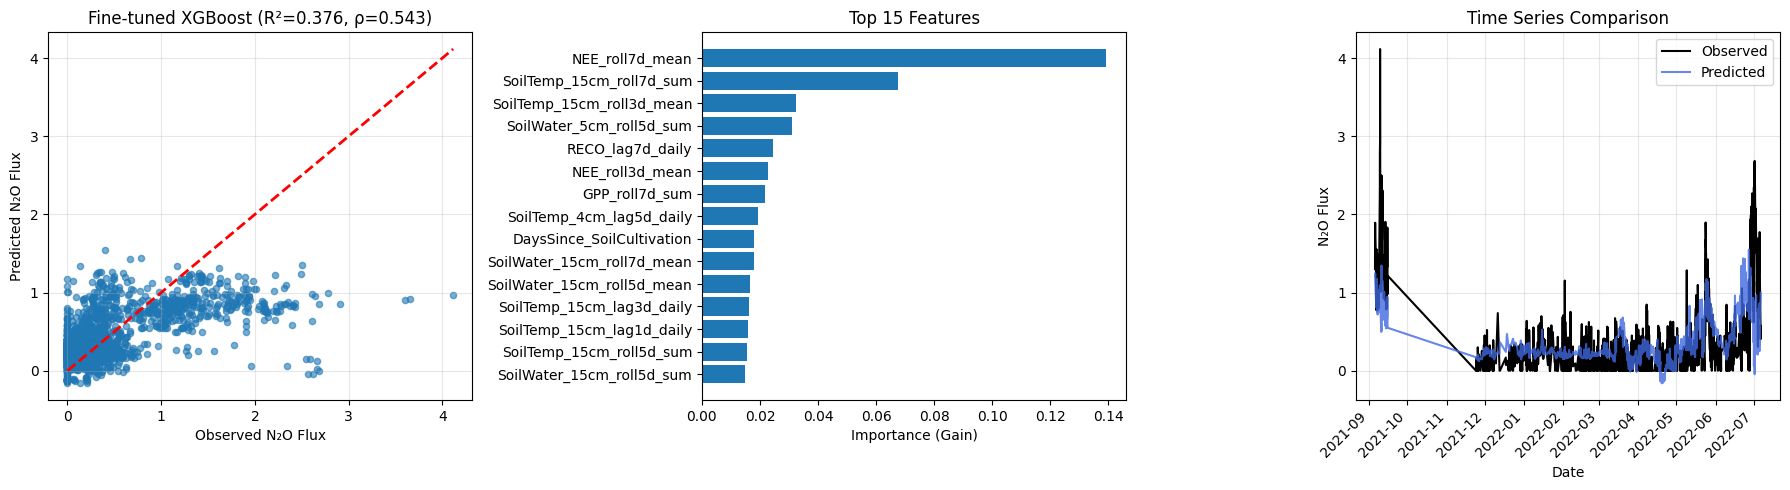


✓ Completed Hourly | Augmented
  Optimized R²: 0.3759
  Optimized ρ: 0.5434

OPTIMIZING: Daily | Base
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.7567
Completed 20/200 iterations. Best R²: 0.7567
Completed 30/200 iterations. Best R²: 0.7567
Completed 40/200 iterations. Best R²: 0.7567
Completed 50/200 iterations. Best R²: 0.7567
Completed 60/200 iterations. Best R²: 0.7567
Completed 70/200 iterations. Best R²: 0.7567
Completed 80/200 iterations. Best R²: 0.7567
Completed 90/200 iterations. Best R²: 0.7567
Completed 100/200 iterations. Best R²: 0.7567
Completed 110/200 iterations. Best R²: 0.7567
Completed 120/200 iterations. Best R²: 0.7602
Completed 130/200 iterations. Best R²: 0.7602
Completed 140/200 iterations. Best R²: 0.7602
Completed 150/200 iterations. Best R²: 0.7602
Completed 160/200 iterations. Best R²: 0.7602
Completed 170/200 iterations. Best R²: 0.7602
Completed 180/200 iterations. Best R²: 0

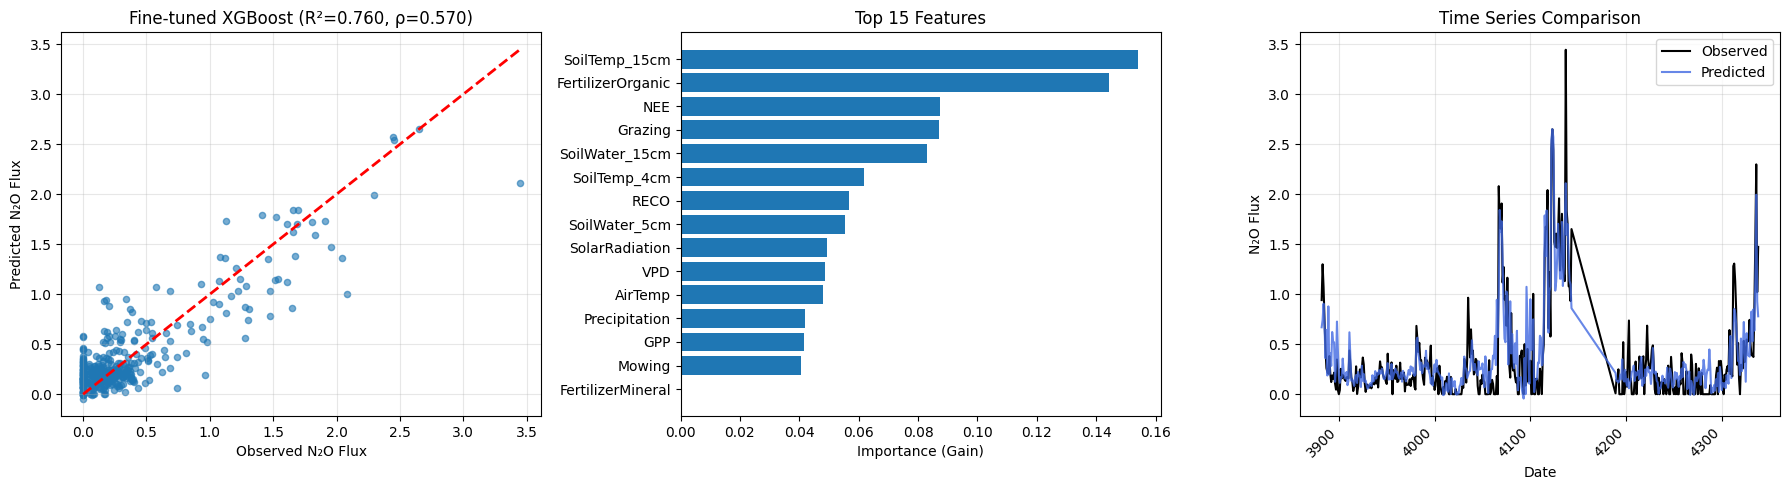


✓ Completed Daily | Base
  Optimized R²: 0.7602
  Optimized ρ: 0.5696

OPTIMIZING: Daily | Lag
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.8294
Completed 20/200 iterations. Best R²: 0.8400
Completed 30/200 iterations. Best R²: 0.8400
Completed 40/200 iterations. Best R²: 0.8400
Completed 50/200 iterations. Best R²: 0.8400
Completed 60/200 iterations. Best R²: 0.8400
Completed 70/200 iterations. Best R²: 0.8400
Completed 80/200 iterations. Best R²: 0.8400
Completed 90/200 iterations. Best R²: 0.8417
Completed 100/200 iterations. Best R²: 0.8417
Completed 110/200 iterations. Best R²: 0.8417
Completed 120/200 iterations. Best R²: 0.8417
Completed 130/200 iterations. Best R²: 0.8417
Completed 140/200 iterations. Best R²: 0.8417
Completed 150/200 iterations. Best R²: 0.8417
Completed 160/200 iterations. Best R²: 0.8417
Completed 170/200 iterations. Best R²: 0.8417
Completed 180/200 iterations. Best R²: 0.8426
C

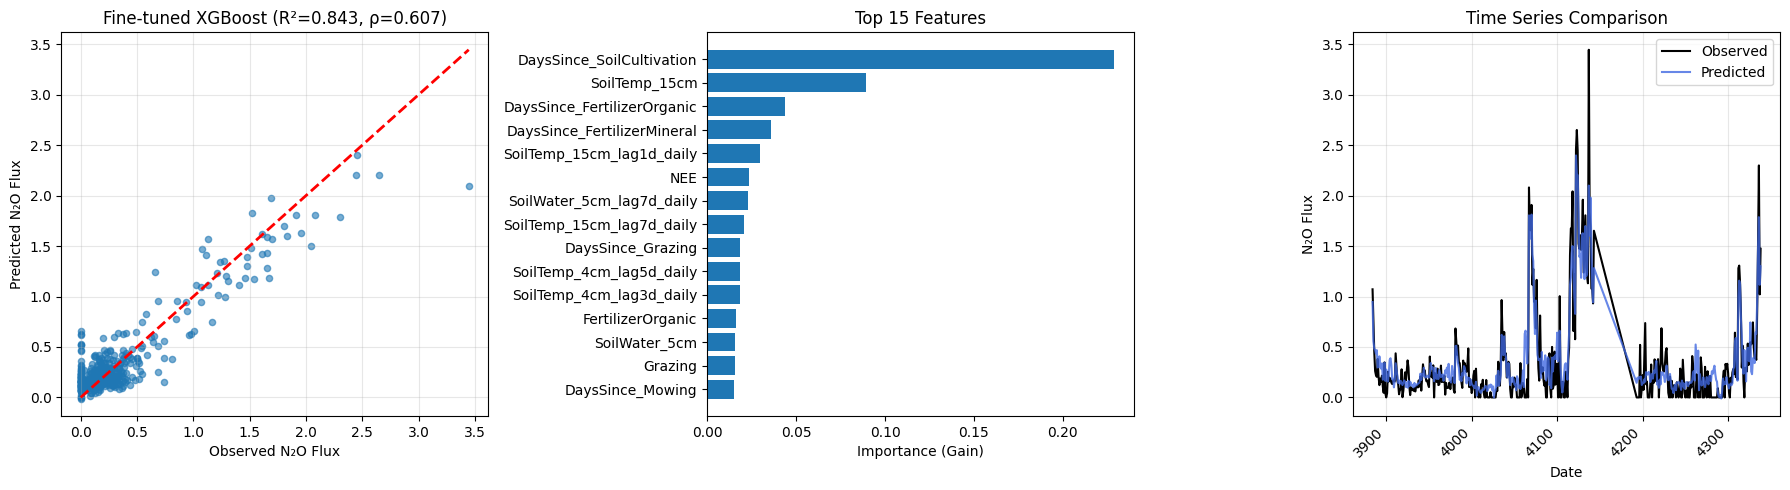


✓ Completed Daily | Lag
  Optimized R²: 0.8426
  Optimized ρ: 0.6075

OPTIMIZING: Daily | Augmented
Starting hyperparameter search...
Search type: random
Random search iterations: 200
Completed 10/200 iterations. Best R²: 0.7868
Completed 20/200 iterations. Best R²: 0.8112
Completed 30/200 iterations. Best R²: 0.8140
Completed 40/200 iterations. Best R²: 0.8140
Completed 50/200 iterations. Best R²: 0.8303
Completed 60/200 iterations. Best R²: 0.8303
Completed 70/200 iterations. Best R²: 0.8303
Completed 80/200 iterations. Best R²: 0.8303
Completed 90/200 iterations. Best R²: 0.8303
Completed 100/200 iterations. Best R²: 0.8303
Completed 110/200 iterations. Best R²: 0.8303
Completed 120/200 iterations. Best R²: 0.8303
Completed 130/200 iterations. Best R²: 0.8303
Completed 140/200 iterations. Best R²: 0.8303
Completed 150/200 iterations. Best R²: 0.8303
Completed 160/200 iterations. Best R²: 0.8303
Completed 170/200 iterations. Best R²: 0.8303
Completed 180/200 iterations. Best R²: 0.8

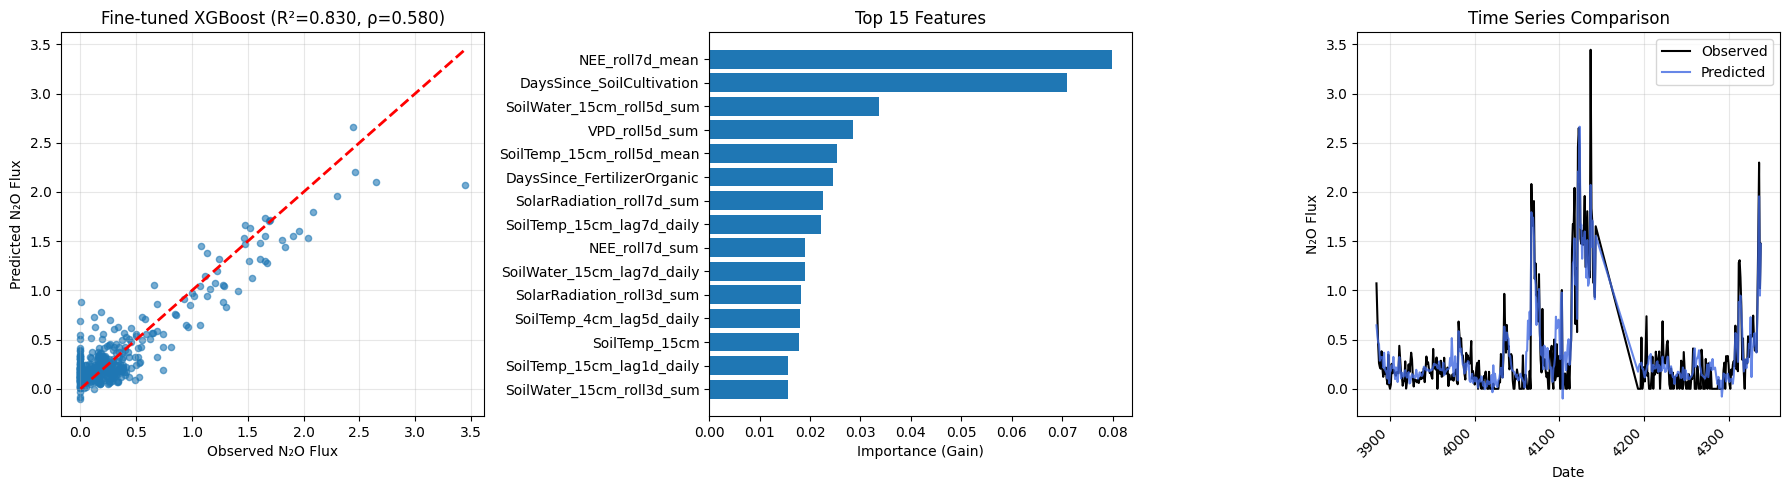


✓ Completed Daily | Augmented
  Optimized R²: 0.8303
  Optimized ρ: 0.5799


In [32]:
# Define all configurations
configurations = [
    ("Hourly", "Base", chamau_lag, base_predictors),
    ("Hourly", "Lag", chamau_lag, lag_predictors),
    ("Hourly", "Augmented", chamau_lag, augmented_predictors),
    ("Daily", "Base", chamau_daily, base_predictors),
    ("Daily", "Lag", chamau_daily, lag_predictors),
    ("Daily", "Augmented", chamau_daily, augmented_predictors),
]

# Store all results
all_optimized_results = []
all_best_params = {}

# Loop through all configurations
for temporal, pred_type, df, predictors in configurations:
    
    print("\n" + "="*80)
    print(f"OPTIMIZING: {temporal} | {pred_type}")
    print("="*80)
    
    # Step 1: Hyperparameter search
    best_params, search_results = hyperparameter_search_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        search_type='random',
        n_iter=200, 
        random_state=42
    )
    
    # Store best params
    all_best_params[f"{temporal}_{pred_type}"] = best_params
    
    # Step 2: Train final model with best params
    final_results = train_final_model(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        best_params=best_params,
        test_size=0.1,
        random_state=42,
        plot=True
    )
    
    # Store results
    all_optimized_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_optimized': final_results['r2'],
        'Spearman_optimized': final_results['spearman_rho'],
        'Best_Params': best_params
    })
    
    print(f"\n✓ Completed {temporal} | {pred_type}")
    print(f"  Optimized R²: {final_results['r2']:.4f}")
    print(f"  Optimized ρ: {final_results['spearman_rho']:.4f}")

In [33]:
def train_xgb_timeseries(df, predictors, target, test_size=0.1, n_estimators=300, random_state=42, plot=True):

    df = df.sort_index().copy()
    X = df[predictors]
    y = df[target]

    mask = X.notna().all(axis=1) & y.notna()
    X, y = X[mask], y[mask]
    offset = abs(y.min()) + 1e-6
    y_shifted = y + offset

    split_idx = int(len(X) * (1 - test_size))
    X_train, X_test = X.iloc[:split_idx], X.iloc[split_idx:]
    y_train, y_test = y_shifted.iloc[:split_idx], y_shifted.iloc[split_idx:]

    test_dates = X_test.index
    time_train = (df.index.min(), df.index[:split_idx].max())
    time_test = (df.index[split_idx], df.index.max())

    print(f"Train period: {time_train[0]} → {time_train[1]}")
    print(f"Test  period: {time_test[0]} → {time_test[1]}")

    model = XGBRegressor(
        n_estimators=n_estimators, 
        max_depth=6, 
        learning_rate=0.1, 
        subsample=0.8, 
        colsample_bytree=0.8, 
        random_state=random_state, 
        n_jobs=-1
    )
    model.fit(X_train, y_train, verbose=False)

    y_pred = model.predict(X_test)
    y_pred_lin = y_pred - offset
    y_test_lin = y_test - offset

    r2 = r2_score(y_test_lin, y_pred_lin)
    rho, _ = spearmanr(y_test_lin, y_pred_lin)
    importances = pd.Series(model.feature_importances_, index=predictors).sort_values(ascending=False)

    print("\nModel evaluation:")
    print(f"  R² (linear scale): {r2:.3f}")
    print(f"  Spearman ρ:        {rho:.3f}")

    if plot:
        fig, axes = plt.subplots(1, 3, figsize=(18, 5))
        axes[0].scatter(y_test_lin, y_pred_lin, alpha=0.6, s=20)
        min_val, max_val = y_test_lin.min(), y_test_lin.max()

        axes[0].plot([min_val, max_val], [min_val, max_val], "r--", lw=2)
        axes[0].set_xlabel("Observed N₂O Flux")
        axes[0].set_ylabel("Predicted N₂O Flux")
        axes[0].set_title(f"XGBoost (R²={r2:.3f}, ρ={rho:.3f})")
        axes[0].grid(True, alpha=0.3)
        top_features = importances.head(15)

        axes[1].barh(range(len(top_features)), top_features.values)
        axes[1].set_yticks(range(len(top_features)))
        axes[1].set_yticklabels(top_features.index)
        axes[1].set_xlabel("Importance (Gain)")
        axes[1].set_title("Top 15 Features")
        axes[1].invert_yaxis()

        axes[2].plot(test_dates, y_test_lin.values, label="Observed", color="black", lw=1.5)
        axes[2].plot(test_dates, y_pred_lin, label="Predicted", color="royalblue", lw=1.5, alpha=0.8)
        axes[2].set_xlabel("Date")
        axes[2].set_ylabel("N₂O Flux")
        axes[2].set_title("Time Series Comparison")
        axes[2].legend()
        axes[2].grid(True, alpha=0.3)

        plt.setp(axes[2].xaxis.get_majorticklabels(), rotation=45, ha='right')
        plt.tight_layout()
        plt.show()

    return {
        "model": model, 
        "r2": r2, 
        "spearman_rho": rho, 
        "feature_importance": importances, 
        "y_test": y_test_lin, 
        "y_pred": y_pred_lin, 
        "test_dates": test_dates
    }

In [34]:
# Re-run original models for comparison
original_results = []

for temporal, pred_type, df, predictors in configurations:
    print(f"\nRunning original {temporal} | {pred_type}...")
    
    orig = train_xgb_timeseries(
        df=df,
        predictors=predictors,
        target="N2O_Flux_ln",
        test_size=0.1,
        n_estimators=300,
        random_state=42,
        plot=False
    )
    
    original_results.append({
        'Temporal': temporal,
        'Predictors': pred_type,
        'R2_original': orig['r2'],
        'Spearman_original': orig['spearman_rho']
    })

# Combine results
comparison_df = pd.merge(
    pd.DataFrame(original_results),
    pd.DataFrame(all_optimized_results),
    on=['Temporal', 'Predictors']
)

# Calculate improvements
comparison_df['R2_improvement'] = comparison_df['R2_optimized'] - comparison_df['R2_original']
comparison_df['Spearman_improvement'] = comparison_df['Spearman_optimized'] - comparison_df['Spearman_original']

print("\n" + "="*80)
print("COMPREHENSIVE COMPARISON: ORIGINAL VS OPTIMIZED")
print("="*80)
print(comparison_df[['Temporal', 'Predictors', 'R2_original', 'R2_optimized', 
                     'R2_improvement', 'Spearman_original', 'Spearman_optimized', 
                     'Spearman_improvement']].to_string(index=False))


Running original Hourly | Base...
Train period: 2014-01-01 08:15:00 → 2021-07-31 12:15:00
Test  period: 2021-07-31 13:15:00 → 2022-07-06 09:15:00

Model evaluation:
  R² (linear scale): 0.145
  Spearman ρ:        0.321

Running original Hourly | Lag...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00

Model evaluation:
  R² (linear scale): 0.269
  Spearman ρ:        0.528

Running original Hourly | Augmented...
Train period: 2014-01-01 08:15:00 → 2021-06-29 15:45:00
Test  period: 2021-06-29 17:15:00 → 2022-07-06 09:15:00

Model evaluation:
  R² (linear scale): 0.283
  Spearman ρ:        0.553

Running original Daily | Base...
Train period: 0 → 3689
Test  period: 3690 → 4338

Model evaluation:
  R² (linear scale): 0.762
  Spearman ρ:        0.582

Running original Daily | Lag...
Train period: 0 → 3642
Test  period: 3643 → 4338

Model evaluation:
  R² (linear scale): 0.831
  Spearman ρ:        0.626

Running original Daily |

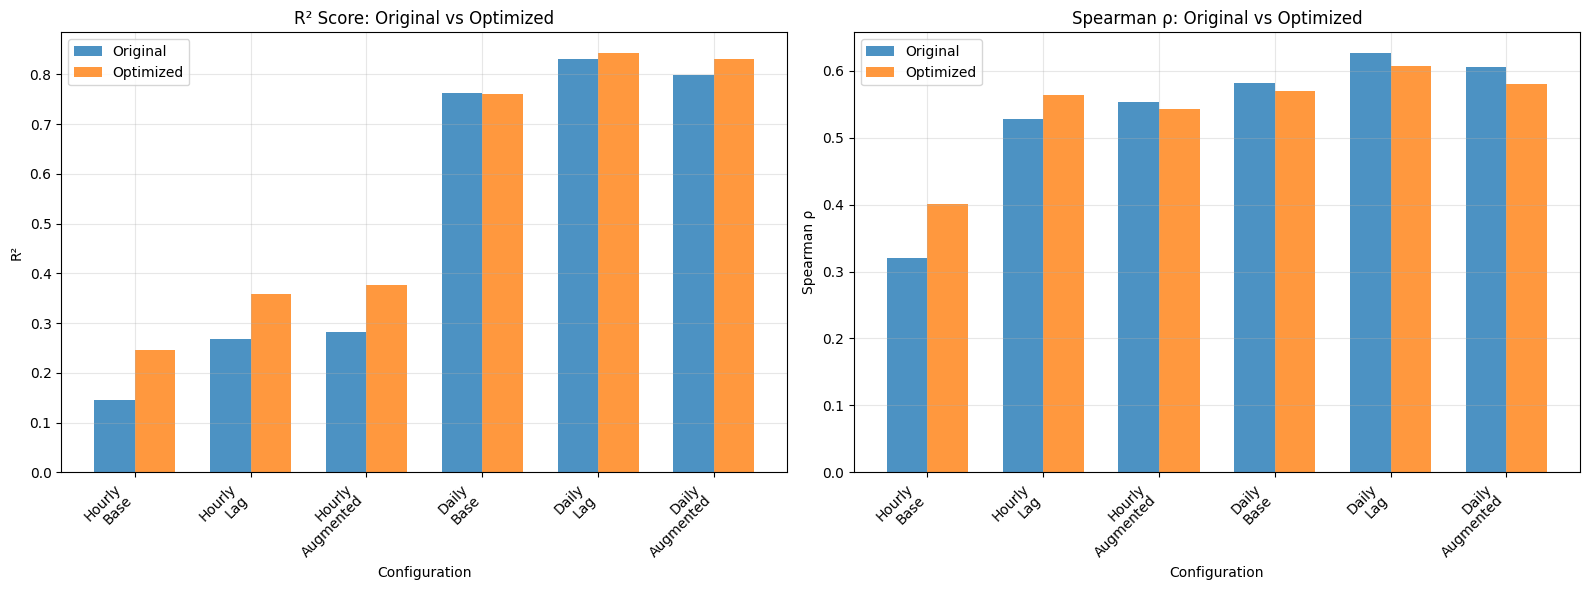

In [35]:
fig, axes = plt.subplots(1, 2, figsize=(16, 6))
x = np.arange(len(comparison_df))
width = 0.35

axes[0].bar(x - width/2, comparison_df['R2_original'], width, label='Original', alpha=0.8)
axes[0].bar(x + width/2, comparison_df['R2_optimized'], width, label='Optimized', alpha=0.8)
axes[0].set_xlabel('Configuration')
axes[0].set_ylabel('R²')
axes[0].set_title('R² Score: Original vs Optimized')
axes[0].set_xticks(x)
axes[0].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[0].legend()
axes[0].grid(True, alpha=0.3)
axes[1].bar(x - width/2, comparison_df['Spearman_original'], width, label='Original', alpha=0.8)
axes[1].bar(x + width/2, comparison_df['Spearman_optimized'], width, label='Optimized', alpha=0.8)
axes[1].set_xlabel('Configuration')
axes[1].set_ylabel('Spearman ρ')
axes[1].set_title('Spearman ρ: Original vs Optimized')
axes[1].set_xticks(x)
axes[1].set_xticklabels([f"{row['Temporal']}\n{row['Predictors']}" for _, row in comparison_df.iterrows()], rotation=45, ha='right')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [36]:
print("\n" + "="*80)
print("BEST HYPERPARAMETERS FOR EACH CONFIGURATION")
print("="*80)
for config_name, params in all_best_params.items():
    print(f"\n{config_name}:")
    for key, value in params.items():
        print(f"  {key}: {value}")


BEST HYPERPARAMETERS FOR EACH CONFIGURATION

Hourly_Base:
  n_estimators: 300
  max_depth: 6
  learning_rate: 0.2
  subsample: 0.6
  colsample_bytree: 0.8
  min_child_weight: 1
  gamma: 0.5

Hourly_Lag:
  n_estimators: 100
  max_depth: 6
  learning_rate: 0.2
  subsample: 0.6
  colsample_bytree: 0.7
  min_child_weight: 3
  gamma: 0.5

Hourly_Augmented:
  n_estimators: 200
  max_depth: 5
  learning_rate: 0.2
  subsample: 0.7
  colsample_bytree: 0.6
  min_child_weight: 3
  gamma: 0.2

Daily_Base:
  n_estimators: 300
  max_depth: 8
  learning_rate: 0.1
  subsample: 0.8
  colsample_bytree: 0.8
  min_child_weight: 5
  gamma: 0.0

Daily_Lag:
  n_estimators: 100
  max_depth: 8
  learning_rate: 0.1
  subsample: 0.7
  colsample_bytree: 0.9
  min_child_weight: 5
  gamma: 0.0

Daily_Augmented:
  n_estimators: 500
  max_depth: 4
  learning_rate: 0.2
  subsample: 0.7
  colsample_bytree: 0.9
  min_child_weight: 3
  gamma: 0.1
